# DCGAN model to generate fake images

**Problem statement:** 

> Design a DCGAN model that can generate few fake images based on the input provided.

**Dataset Description:** 

> Fashion-MNIST dataset is a collection of 6000 greyscale images, with pixel values from 0 to 255. 
> The dimension of each image is 28X28X1.
> We normalize the dataset before processing it to convert the values in the range 0 to 1. 

## Build the Generator 

The Generator Network uses the principle of Transpose Convolution/ Up sampling /De-convolution. The input to the generator network is the noise (z). The output of the generator network is the fake data which is expected to resemble real data more and more as the training progresses. 

### Transpose Convolution or Fractionally-strided Convolution 

Convolution technique uses a filter sliding over an input and resulting in an output which is typically of smaller size compared to the input. In case of Transpose Convolution, we pad the input with zeroes adequately, and slide the kernel across, to get an output that is larger than the input size. Transpose Convolution with a stride of 1, retains the dimensions. Increasing the stride increases the dimensions (Height / Width) of the output.

Example: Upsampling a 2X2 matrix into a 4X4 matrix as shown.
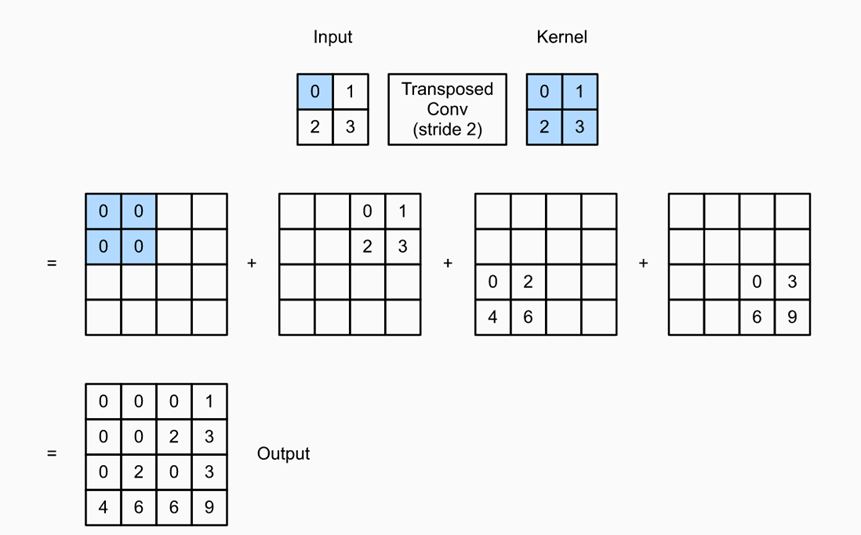

Impact of padding on transpose convolution: Using ‘SAME’ value for padding implies that the output dimension will be input dimension multiplied by the stride value. Thus, if the input shape is 4X4, padding = same and stride=2, then the output shape will be (4X2 = 8), i.e., 8X8. If the padding value is ‘VALID' and the kernel_size larger  than the stride, then we add the difference to the height and width of the input.

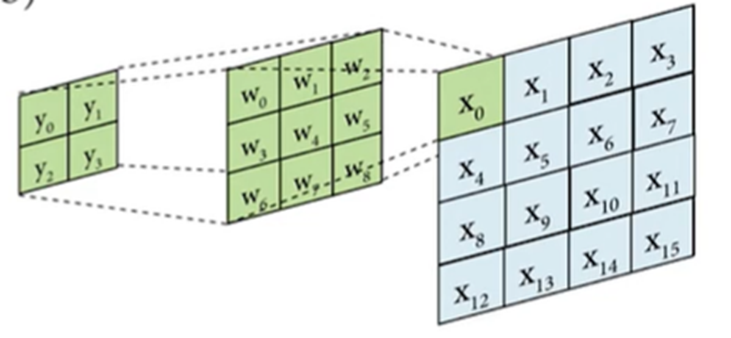

## DCGAN Generator Network

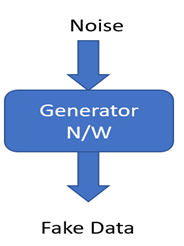

Let us have a look at how to construct the generator network for the DCGAN. We know that this network will take in the noise input vector whose size we can decide. Let the noise vector be say a 100X1 vector. The size of the output will be determined by the size of the real input data, a this is the same data size that the generator will generate.  For our example here, we will use the Fashion MNIST dataset of 60,000 greyscale images each of size 28X28X1. 

-  Only the first Dense layer is a fully connected layer. 
-  We will use 3 fractional-strided convolutional layers for the generator.
-  We will apply batch normalization before every activation 
-  We will use ReLU activation in generator for all layers except for the output, for which we will use the sigmoid activation. Note that if you use tanh activation, you may standardize the values in the range -1 to 1, rather than 0 to 1 by using z-transform.

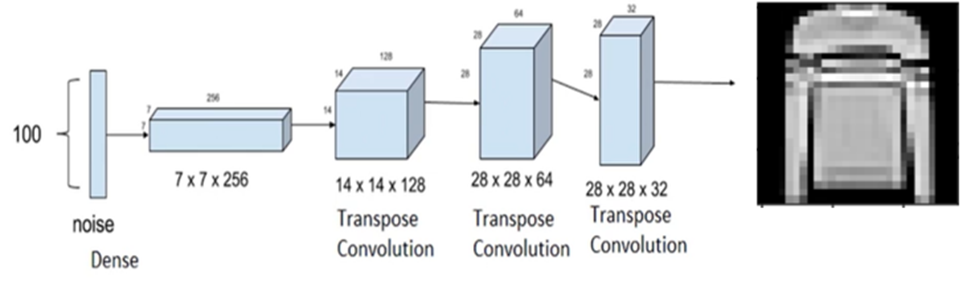

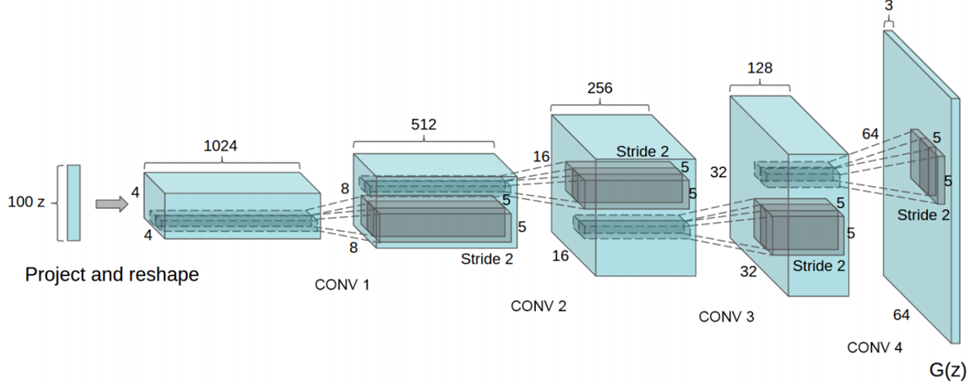

Image from original DCGAN Paper : Radford, Alec et al. “Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks.” CoRR abs/1511.06434 (2016)"

## Build the Discriminator

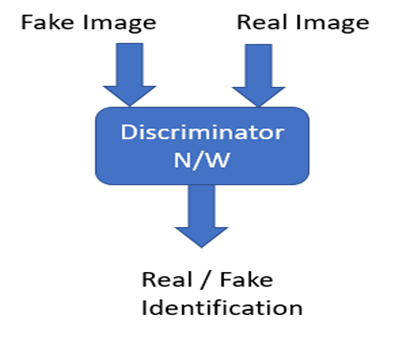

The Discriminator is a regular convolution network, which gives a single Boolean output to mark real or fake images. We build the discriminator as follows:

-  We use 4 Strided Convolution layers. Though this increases the number of trainable parameters, it improves the representational capability of the network.
-  Use LeakyReLU activation in the discriminator for all layers except last layer which uses Sigmoid.
-  Note that while this network does not use Batch Normalization for discriminator, the same can be used as recommended. 

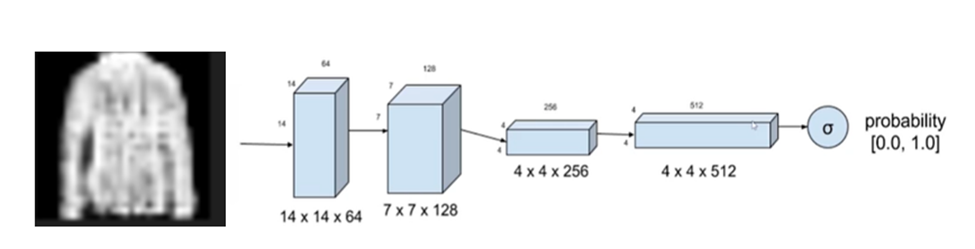

The dimensions of the fake data dimensions are similar to that of the real data, which are 28X28X1, in this case. For the discriminator, the original dataset acts like a ground truth. The fake image is analyzed by the discriminator for prediction as real or fake. As training progresses, the discriminator finds it difficult to identify fake images as fake.

## Steps to train the DCGAN

We will follow typical steps to train the GAN in our DCGAN network. 

The discriminator is pre-trained with batch size of 256 images. The batch size can be customized as per needs. Its weights are frozen, while training the generator (with the same batch size). The process is repeated for desired number of times.

## DCGAN Losses

> - The DCGAN performs unsupervised representational learning, i.e., learning without using labels of the data. 
> - The discriminator is trained to identify real and fake (generated) images correctly. It is therefore penalized if it classifies real images as fake or vice versa.
> - The generator is penalized, if an image generated by it is identified as fake by the discriminator. Thus, generator loss is high if the generated images are classified as fake. 
> - Since it is a two-class classification, Binary Cross Entropy loss is used to measure performance of the Discriminator as well as Generator networks. 
> - Below images show the progression of the generator output from 500 to 7000 iterations. Note that the type or class of image generated (e.g., Jacket, Shoe, Pant, etc.) cannot be determined in DCGAN, as the learning is not conditional and not specific to any class label and hence, unsupervised. 

# Code

## Installing packages

In [36]:
%pip install imageio tensorflow numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Importing libraries

In [37]:
import tensorflow as tf
import numpy as np 
import math                     #data normalization
import matplotlib.pyplot as plt #plot images of outputs
import os                       # to read 
import imageio                  # to create anim of outputs
from sklearn import preprocessing #for standardizing the dataset


## Load dataset and visualise

- We are going to use the Fashion-MNIST dataset
- Number of images: 60000
- Dimensions: 28X28X1
- This dataset has objects belonging to 10 classes. They are:
    > 0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat, 5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot

We will first load the dataset, then visualize some sample images from the dataset.

(60000, 28, 28) (60000,)


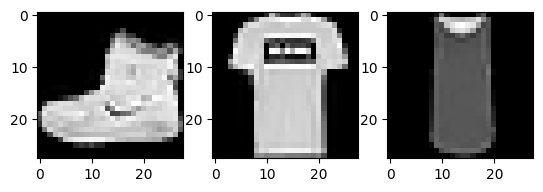

In [38]:
# Load the Fashion MNIST dataset
(x_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
print(x_train.shape, y_train.shape)

# plotting
for i in range(3):  # we plot 3 images
    plt.subplot(1, 3, 1 + i)
    plt.imshow(x_train[i], cmap='gray')
plt.show()

## Building the Generator Network

Since the generator will up-sample the noise vector, we will use Conv2DTranspose module from Tensorflow. We create the network which performs the following transforms.

Input the Noise (100X1) to a Dense Layer (7X7X256) followed by series of up-sampling layers Conv2DTranspose to reach the desired image size (28X28X1)

In [39]:
#Convert the train dataset into a 3D DATASET of stacked 3D images 
image_width = x_train.shape[1];
x_train = np.reshape(x_train, [-1, image_width ,image_width , 1]).astype('float32')

#Check the shape of the data now
x_train.shape

(60000, 28, 28, 1)

## Normalization

We will now standardize the data values. Currently the range of values is from 0 to 255. We may either modify it to be between 0 and 1 or between -1 to 1. If we intend to use the tanh activation function in the last layer, we may use the range -1 to 1 or use the range 0 to 1 for sigmoid activation in the output layer
Now, let use standardize the values

In [40]:
# Normalize the images to [-1, 1] [Normalized Value = (value - mean)/mean]
x_train = (x_train - 127.5) / 127.5  

#Generator Initializations
noise_length = 100

## Building the network

We will use the Tensorflow functional API to build our network. By default the function considers a noise input size of 100, and image size of 28. Both parameters can be customized when the function is called.
We manipulate the stride in order to increase the dimensions of the input from 7 to 28 and maniputate the filter count to downsize the output to 1 channel in the last layer.

### Generator Model

In [41]:
def create_generator_model(image_size=28, noise_input=100):
   
   #Create input layer
   input_layer = tf.keras.layers.Input(shape=(noise_input,))
   
   #First upsampling to 7X7X256 
   #Increase dimensions and resize to 3D to feed it to Conv2DTranspose layer
   x = tf.keras.layers.Dense(7 * 7 * 256)(input_layer)
   x = tf.keras.layers.Reshape((7, 7, 256))(x)
   
   #Upscaling 1 : 128 filters, (2,2) stride
   #Input = 7X7X256
   #Output at this stage = 14X14X128
   #Syntax Note: kernel size can be specified as a tuple or integer or list
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.Activation('leaky_relu')(x)
   x = tf.keras.layers.Conv2DTranspose(128, (5,5), strides=2, padding='same')(x)
   
   #Upscaling 2
   #Input = 14X14X128
   #Output at this stage = 28X28X64
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.Activation('leaky_relu')(x)
   x = tf.keras.layers.Conv2DTranspose(64, kernel_size=[5,5], strides=2, padding='same')(x)
   
   #Upscaling 3
   #Input = 28X28X64
   #Output at this stage = 28X28X32
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.Activation('leaky_relu')(x)
   x = tf.keras.layers.Conv2DTranspose(32, kernel_size=[5,5], strides=1, padding='same')(x)
   
   #Upscaling 4
   #Input = 28X28X32
   #Output at this stage = 28X28X1
   #Note that we use tanh activation and not Leaky Relu for the last layer. 
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.Conv2DTranspose(1, kernel_size=[5,5], strides=1, padding='same')(x)
   
   x = tf.keras.layers.Activation('sigmoid')(x)
   #Create the model    
   gen_network = tf.keras.models.Model(input_layer, x, name='gen_network')
   
   return gen_network

### Discriminator Model

In [42]:
def create_discriminator_model(desc_data=[28,28,1]):
      
   #A typical Convolution  network for classification is built  
   disc_input = tf.keras.layers.Input(shape=desc_data)
   #Input Dimension : 28X28X1
   #Output Dimension : 14X14X32
   x = tf.keras.layers.LeakyReLU(alpha=0.2)(disc_input)
   x = tf.keras.layers.Conv2D(32, kernel_size=[5,5], strides=2, padding='same')(x)
   
   #Input Dimension : 14X14X32
   #Output Dimension : 7X7X64
   x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
   x = tf.keras.layers.Conv2D(64, kernel_size=[5,5], strides=2, padding='same')(x)
   
   #Input Dimension : 7X7X64
   #Output Dimension : 4X4X128
   x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
   x = tf.keras.layers.Conv2D(128, kernel_size=[5,5], strides=2, padding='same')(x)
   
   #Input Dimension : 4X4X128
   #Output Dimension : 4X4X256
   x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
   x = tf.keras.layers.Conv2D(256, kernel_size=[5,5], strides=1, padding='same')(x)
   
   #Input Dimension : Flattened(4X4X256)
   #Output Dimension : 1
   #Flatten the output and build an output layer
   x = tf.keras.layers.Flatten()(x)
   x = tf.keras.layers.Dense(1, activation='sigmoid')(x)
   
   #Build Model
   disc_network = tf.keras.models.Model(disc_input, x, name='disc_network')
   
   return disc_network

## Testing the Generator and Discriminator network

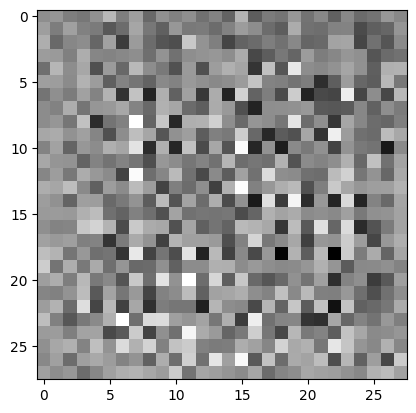

In [43]:
rator = create_generator_model()
noise = tf.random.normal([1, 100])
generated_image = rator(noise, training=False)
plt.imshow(generated_image[0, :, :, 0], cmap='gray')

In [44]:
#This code will check the functioning of the descriminator against a sample input. As of this point, 
#the descriminator is untrained.
discriminator = create_discriminator_model()
decision = discriminator(generated_image)
print (decision)

tf.Tensor([[0.49825662]], shape=(1, 1), dtype=float32)


/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


## Building Models Method

In [45]:
def build_models():
   
   noise_size = 100
   lr = 2e-4
   decay = 6e-8
   
   #Build Base Discriminator model
   base_discriminator = create_discriminator_model(desc_data=(28,28,1,))
   
   #Define optimizer and compile model
   discriminator = tf.keras.models.Model(inputs=base_discriminator.inputs, 
                                         outputs=base_discriminator.outputs)
   optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr, decay=decay)
   discriminator.compile(loss='binary_crossentropy',
                         optimizer=optimizer,
                         metrics=['accuracy'])
   
   #Build Generator model
   generator = create_generator_model(image_size=28, noise_input=noise_size)
   
   #Build Frozen Discriminator
   frozen_discriminator = tf.keras.models.Model(inputs=base_discriminator.inputs, 
                                         outputs=base_discriminator.outputs)
   #Freeze the weights of discriminator during adversarial training
   frozen_discriminator.trainable = False
   #Build Adversarial model
   optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr * 0.5, decay=decay * 0.5)
   #Adversarial = generator + discriminator
   adversarial = tf.keras.models.Model(generator.input, 
                       frozen_discriminator(generator.output))
   
   adversarial.compile(loss='binary_crossentropy',
                       optimizer=optimizer,
                       metrics=['accuracy'])    
   
   return generator, discriminator, adversarial


## Training GAN Method

In [46]:
def train_gan(generator, discriminator, adversarial, noise_size=100):
   
   #Training parameters
   batch_size = 64
   train_steps = 10000   # we are going for 10000 Steps of training
   image_size = 28
   
   #FASHION MNIST DATASET 
   (x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
   
   #Convert the train dataset into a DATASET of stacked 3D images Dimension: (60000,28,28,1)
   x_train = np.reshape(x_train, [-1, image_size, image_size, 1]).astype('float32')
   
   #Standardize data : 0 to 1
   x_train = x_train / 255
   
   #Input for testing generator at different intervals, we will generate 16 images
   test_noise_input = np.random.uniform(-1.0,1.0, size=[16, noise_size])
   
   #Start training
   for i in range(train_steps):
       
       #Train the DISCRIMATOR
       
       #Step 1. Get images generated by Generator N/W (Fake Images)
       noise_input = np.random.uniform(-1.0,1.0, size=[batch_size, noise_size])
       fake_images = generator.predict(noise_input)
       
       #Step 2. Get images from actual  training set (Real Images)
       img_indexes = np.random.randint(0, x_train.shape[0], size=batch_size)
       real_images = x_train[img_indexes]
       
       #Step 3. Prepare input for training Discriminator
       X = np.concatenate((real_images, fake_images))
       
       #4. Labels for training
       y_real = np.ones((batch_size, 1))
       y_fake = np.zeros((batch_size, 1))
       y = np.concatenate((y_real, y_fake))
       
       #5. Train the Discriminator Network
       # The train_on_batch() method Runs a single gradient update on a single batch of data.
       d_loss, d_acc = discriminator.train_on_batch(X, y)
       
       # Now we have updated discriminator weights.We will freeze the discriminator weights to 
       #train the adversarial network 
       
       #Train ADVERSARIAL Network
       
       #1. Prepare input - create a new batch of noise
       X = noise_input = np.random.uniform(-1.0,1.0, size=[batch_size, noise_size])
       
       #2. Prepare labels - training Adversarial network to lie :) - All 1s
       y = np.ones((batch_size, 1))
       
       #3. Train - Pls note Discrimator is not getting trained here
       a_loss, a_acc = adversarial.train_on_batch(X, y)
       
       if i % 100 == 0:
           #Print loss and Accuracy for both networks
           print("%s [Discriminator loss: %f, acc: %f, Adversarial loss: %f, acc: %f]" % (i, d_loss, d_acc, a_loss, a_acc) )
       
       #Save generated images to see how well Generator is doing
       if (i+1) % 500 == 0:
           
           #Generate 16 images
           fake_images = generator.predict(test_noise_input)
           
           #Display images
           plot_images(fake_images, i+1)
           
   #Save Generator model
   generator.save('fashionmnist_generator_dcgan.h5')    


## Plot Images Method

In [47]:
def plot_images(fake_images, step):
   
   plt.figure(figsize=(2.5,2.5))
   num_images = fake_images.shape[0]
   
   image_size = fake_images.shape[1]
   rows = int(math.sqrt(fake_images.shape[0]))
   
   for i in range(num_images):
       plt.subplot(rows, rows, i + 1)
       image = np.reshape(fake_images[i], [image_size, image_size])
       plt.imshow(image, cmap='gray')
       plt.axis('off')
   plt.show()

In [ ]:
G, D, A = build_models()
G.summary()
D.summary()
train_gan(G, D, A, noise_size=noise_length)

/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "gen_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 12544)          │     1,266,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_8 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_32             │ (None, 14, 14, 128)    │       819,328 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_33             │ (None, 28, 28, 64)     │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_34             │ (None, 28, 28, 32)     │        51,232 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_35             │ (None, 28, 28, 1)      │           801 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,345,089 (8.95 MB)

 Trainable params: 2,344,129 (8.94 MB)

...

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,080,577 (4.12 MB)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step


/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [Discriminator loss: 0.690915, acc: 0.492188, Adversarial loss: 0.685387, acc: 0.984375]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 376ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step
2/2 ━━━━━━━━

## Create an animation of the generated images

In [ ]:
import glob
import imageio
anim_file = 'dcfashiongan.gif'
with imageio.get_writer(anim_file, mode='I') as writer:
 filenames = glob.glob('D:\Sups\Python\GAN\FASHION_mnist\*.png')
 filenames = sorted(filenames)
 for filename in filenames:
   image = imageio.imread(filename)
   writer.append_data(image)
 image = imageio.imread(filename)
 writer.append_data(image)